In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing



In [8]:

# Create synthetic weekly seasonal data (ice-cream sales example)
np.random.seed(42)
days = np.arange(1, 180)
trend = 2 * days
seasonal = 10 * np.sin(2 * np.pi * days / 7) # weekly pattern
noise = np.random.normal(0, 2, len(days))
y = 50 + trend + seasonal + noise

In [9]:
import plotly.express as px

px.line(x=days, y=y, title='Synthetic weekly Seasonal Data',
        labels={'x':"Days", 'y':'Ice-cream sales'}).show()

In [10]:
# Fit Holt-Winters (additive trend & seasonality)
model = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=7)
fit = model.fit()
forecast = fit.forecast(30)

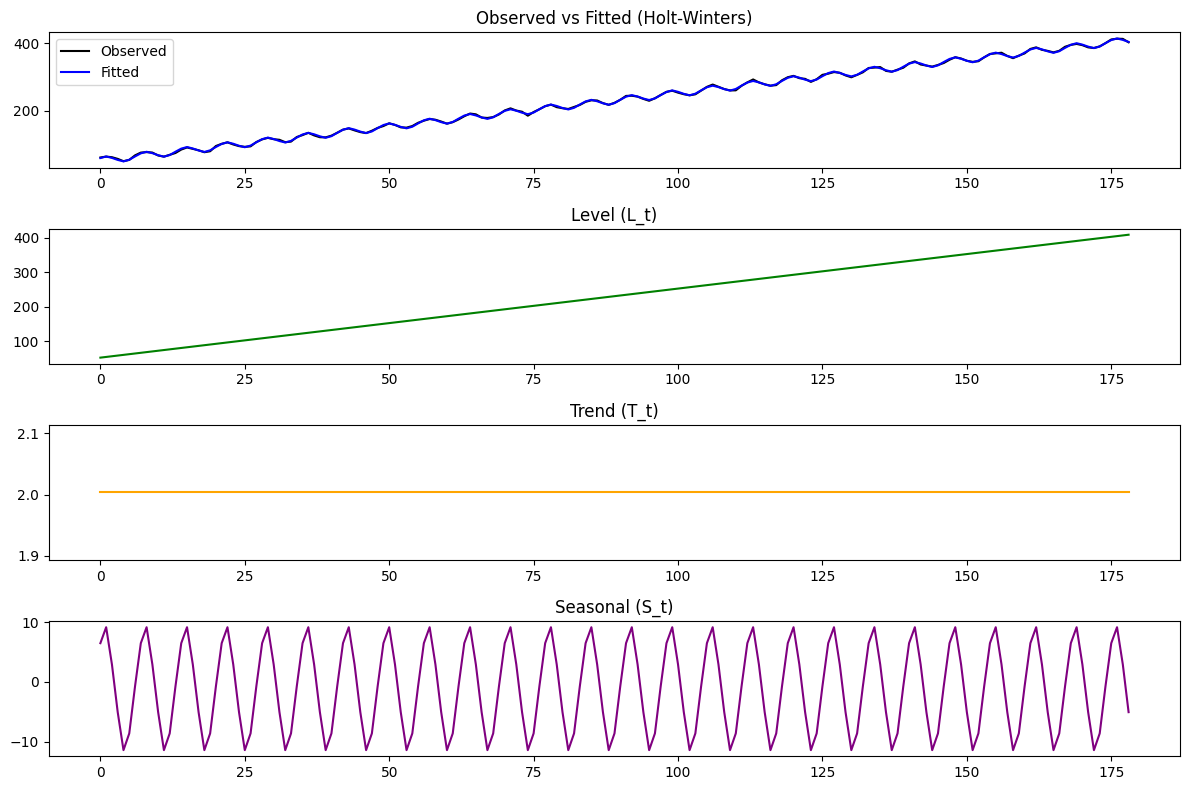

In [11]:
# Plot decomposition-style view
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(y, label='Observed', color='black')
plt.plot(fit.fittedvalues, label='Fitted', color='blue')
plt.title('Observed vs Fitted (Holt-Winters)')
plt.legend()


plt.subplot(4, 1, 2)
plt.plot(fit.level, color='green')
plt.title('Level (L_t)')


plt.subplot(4, 1, 3)
plt.plot(fit.trend, color='orange')
plt.title('Trend (T_t)')


plt.subplot(4, 1, 4)
plt.plot(fit.season, color='purple')
plt.title('Seasonal (S_t)')
plt.tight_layout()
plt.show()

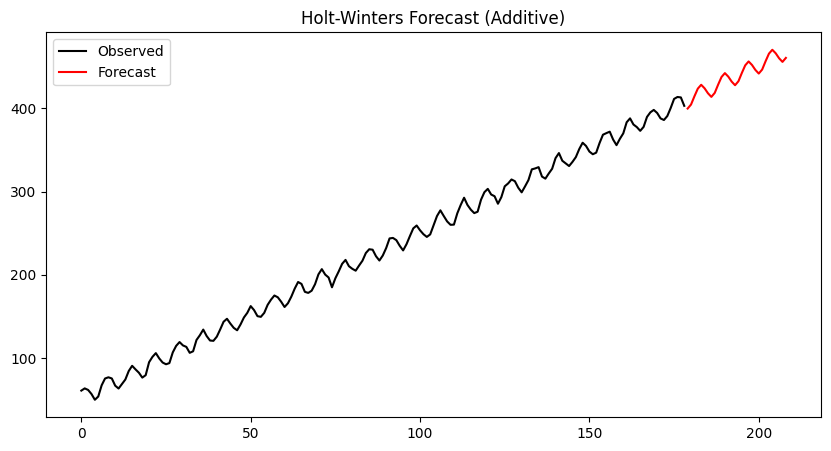

In [12]:
# Forecast plot
plt.figure(figsize=(10, 5))
plt.plot(y, label='Observed', color='black')
plt.plot(np.arange(len(y), len(y)+len(forecast)), forecast, label='Forecast', color='red')
plt.title('Holt-Winters Forecast (Additive)')
plt.legend()
plt.show()

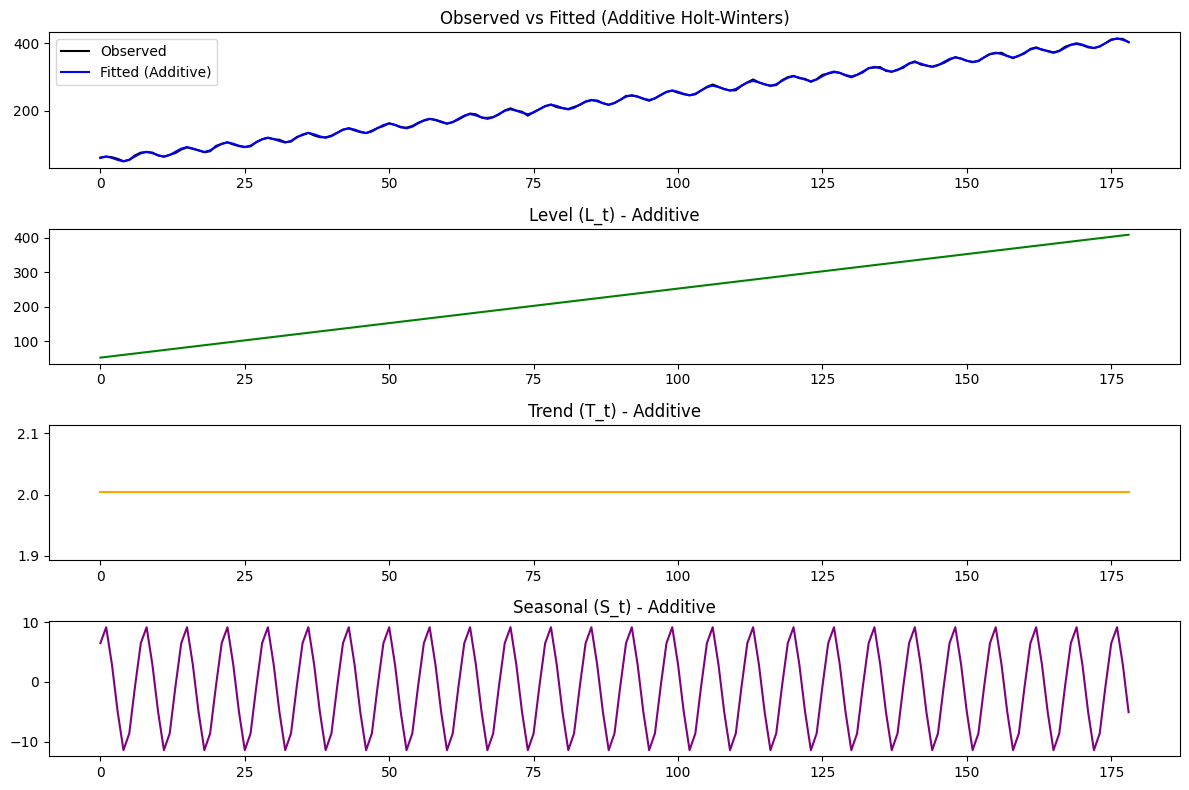

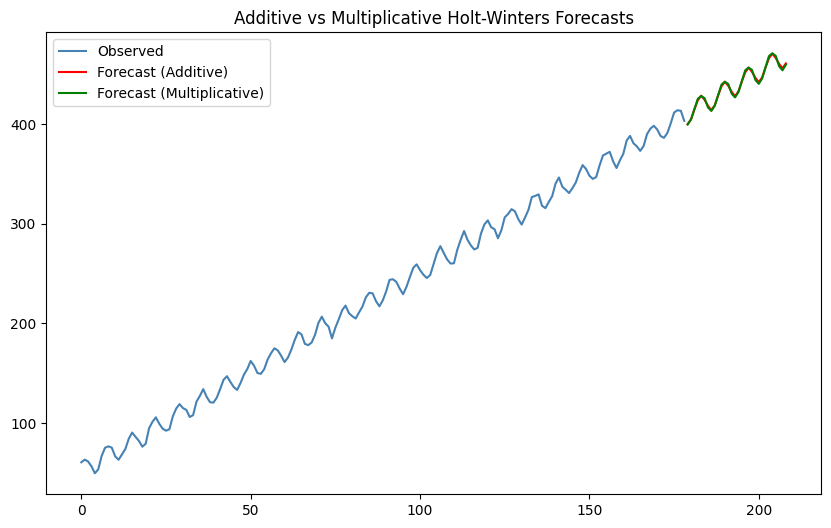

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create synthetic data with stronger trend and weekly seasonality
np.random.seed(42)
days = np.arange(1, 180)
trend = 2.0 * days  # amplified trend
seasonal = 10 * np.sin(2 * np.pi * days / 7)  # weekly pattern
noise = np.random.normal(0, 2, len(days))
y = 50 + trend + seasonal + noise

# Fit additive and multiplicative Holt-Winters models
ets_add = ExponentialSmoothing(y, trend='add', seasonal='add', seasonal_periods=7).fit()
ets_mul = ExponentialSmoothing(y, trend='add', seasonal='mul', seasonal_periods=7).fit()

# Forecasts
fc_add = ets_add.forecast(30)
fc_mul = ets_mul.forecast(30)

# Plot fitted components (additive)
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(y, label='Observed', color='black')
plt.plot(ets_add.fittedvalues, label='Fitted (Additive)', color='blue')
plt.title('Observed vs Fitted (Additive Holt-Winters)')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(ets_add.level, color='green')
plt.title('Level (L_t) - Additive')

plt.subplot(4, 1, 3)
plt.plot(ets_add.trend, color='orange')
plt.title('Trend (T_t) - Additive')

plt.subplot(4, 1, 4)
plt.plot(ets_add.season, color='purple')
plt.title('Seasonal (S_t) - Additive')
plt.tight_layout()
plt.show()

# Compare additive vs multiplicative forecasts
plt.figure(figsize=(10, 6))
plt.plot(y, label='Observed', color='steelblue')
plt.plot(np.arange(len(y), len(y)+len(fc_add)), fc_add, label='Forecast (Additive)', color='red')
plt.plot(np.arange(len(y), len(y)+len(fc_mul)), fc_mul, label='Forecast (Multiplicative)', color='green')
plt.title('Additive vs Multiplicative Holt-Winters Forecasts')
plt.legend()
plt.show()